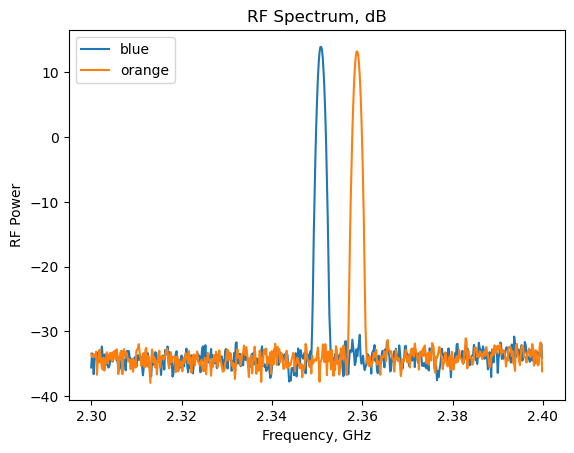

13.936 [280]


In [17]:
import pyvisa as visa
rm=visa.ResourceManager()
rm.list_resources()
Instr19=rm.open_resource('GPIB0::19::INSTR')
Usb0=rm.open_resource('USB0::0x0B5B::0xFFF9::815093_146_11::INSTR')
Instr19.write('freq 2.359000000000E+09')
Instr19.write('power 15 ')
Usb0.timeout=3000
Instr19.timeout=3000
power=Usb0.query("trace:data?")
import time
time.sleep(5)
Instr19.write('freq 2.351000000000E+09')
power2352=Usb0.query("trace:data?")
import numpy as np
import matplotlib.pyplot as plt
power_list=[]
power_axis=[]
power_split=power.split(',')
power_split.pop(0)
power_split.pop(550)
power_list2352=[]

power_split2352=power2352.split(',')
power_split2352.pop(0)
power_split2352.pop(550)
freqStart=Usb0.query('frequency:start?')
freqStop=Usb0.query('frequency:stop?')

for x in range(len(power_split)): 
    power_axis.append(0.000000001*(float(freqStart)+x*(float(freqStop)-float(freqStart))/len(power_split)))
    power_list.append(float(power_split[x]))
    power_list2352.append(float(power_split2352[x]))
plt.plot(power_axis,power_list, label='2358')
plt.plot(power_axis,power_list2352, label = '2352')
plt.title('RF Spectrum, dB') 
plt.xlabel('Frequency, GHz')
plt.ylabel('RF Power')
plt.legend(['blue', 'orange'], loc="upper left")
maxElement=np.max(power_list)
index=np.where(power_list==maxElement)[0]
"""
prevElement=power_list[index-1]
nextElement=power_list[index+1]   
"""
plt.show()
print(maxElement, index)
fp=open('power_array.txt', "w")
fp.write(power)
fp.close()
Instr19.close()
Usb0.close()